In [31]:
import os
import sys
import torch
import os.path
import argparse
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from data import *
from utils import *
from PIL import Image
from datetime import datetime
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import train_test_split

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs

In [32]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=100, help='Total # of samples')
parser.add_argument('--mb_size', type=int, default=100, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=20, help='Dim of latent vector')
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')
parser.add_argument('--x_fdim', type=int, default=128, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=20, help='Input y_fdim. See utils.py')
parser.add_argument('--c_accu', type=float, default=100, help='Input weight on recons_error')

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')
parser.add_argument('--max_epochs', type=int, default=1, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [33]:
xtrain, ipVec_dim, nChannels = get_poem_dataloader(args=opt)

In [34]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

VOCAB = 200_000  # for o200k_base
PAD = tiktoken.get_encoding("o200k_base").eot_token
print(PAD)

199999


In [35]:
def kPCA(X, Y, Z, eps=1e-6):
    print(f'Sizes: X={X.size()}, Y={Y.size()}, Z={Z.size()}')
    # Kernel matrix
    a = X @ X.T + Y @ Y.T + Z @ Z.T  # (B,B)
    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :h_dim]
    s = evals  # (B,)
    return h, s

In [36]:
# Energy function
def my_loss(output1, X, output2, Y, output3, Z):
    # h, s = kPCA(output1, output2)

    o1 = F.normalize(output1.float(), dim=1)
    o2 = F.normalize(output2.float(), dim=1)
    o3 = F.normalize(output3.float(), dim=1)
    h, s = kPCA(o1, o2, o3)

    U = torch.mm(torch.t(output1), h)
    V = torch.mm(torch.t(output2), h)
    W = torch.mm(torch.t(output3), h)

    x_tilde = net_text_de(torch.mm(h, torch.t(U)))
    x_target = net_text_en.emb(X.long())

    y_tilde = net_sent_de(torch.mm(h, torch.t(V)))
    z_tilde = net_len_de(torch.mm(h, torch.t(W)))

    X = X.to(dtype=x_tilde.dtype)
    Y = Y.to(dtype=y_tilde.dtype)
    Z = Z.to(dtype=z_tilde.dtype)

    # cost
    f1 = torch.trace(torch.mm(torch.mm(output1, U), torch.t(h))) + torch.trace(torch.mm(torch.mm(output2, V), torch.t(h))) + torch.trace(torch.mm(torch.mm(output3, W), torch.t(h))) # Add third + of t.trace
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:h_dim]), torch.t(h))))
    f3 = 0.5 * ((torch.trace(torch.mm(torch.t(U), U))) + (torch.trace(torch.mm(torch.t(V), V))) + (torch.trace(torch.mm(torch.t(W), W)))) # Add third + of t.trace

    # Reconstruction losses
    recon_loss2 = torch.nn.MSELoss()

    # PAD = net_text_en.emb.padding_idx  # or pass PAD explicitly

    logits = net_text_de(torch.mm(h, torch.t(U)))     # (B,15,V)
    targets = X.long()                                 # (B,15)

    f4_text = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1),
        ignore_index=PAD
    )

    f4 = f4_text + recon_loss2(y_tilde.view(-1, 4), Y.view(-1, 4)) + recon_loss2(z_tilde.view(-1, 15), Z.view(-1, 15))

    loss = - f1 + f3 + f2 + 0.5 * (- f1 + f3 + f2) ** 2 + 100 * f4
    return loss

In [37]:
net_sent_en = NetSentEn().float().to(opt.device)
net_text_en = NetTextEn(d=32, vocab=VOCAB).float().to(device)
net_len_en = NetLenEn().float().to(opt.device)

net_sent_de = NetSentDe().float().to(opt.device)
net_len_de = NetLenDe().float().to(opt.device)

net_text_de = NetTextDe(
    emb_layer=net_text_en.emb,   # <-- use the encoder’s embedding
).float().to(device)

In [38]:
params = list(net_text_en.parameters()) + list(net_text_de.parameters()) + list(net_sent_en.parameters()) + list(net_sent_de.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=0)

l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost

/opt/anaconda3/envs/MT-GenRKM/lib/python3.12/site-packages/torch/_compile.py:53: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


In [39]:
while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
    permutation = torch.randperm(opt.N)
    avg_loss = 0
    for i, (data_text, data_sent, data_len) in enumerate(xtrain):
        # indices = permutation[i:i + mb_size]

        data_text = data_text.to(opt.device)
        data_sent = data_sent.to(opt.device)
        data_len = data_len.to(opt.device)
        
        output1 = net_text_en(data_text)
        output2 = net_sent_en(data_sent)
        output3 = net_len_en(data_len)

        loss = my_loss(output1, data_text, output2, data_sent, output3, data_len)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.detach().cpu().numpy()
        
    cost = avg_loss

    # Remember lowest cost and save checkpoint
    is_best = cost < l_cost
    l_cost = min(cost, l_cost)
    dirs.save_checkpoint({
        'epochs': t + 1,
        'net_text_en_state_dict': net_text_en.state_dict(),
        'net_text_de_state_dict': net_text_de.state_dict(),
        'net_sent_en_state_dict': net_sent_en.state_dict(),
        'net_sent_de_state_dict': net_sent_de.state_dict(),
        'net_len_en_state_dict': net_len_en.state_dict(),
        'net_len_de_state_dict': net_len_de.state_dict(),
        'l_cost': l_cost,
        'optimizer': optimizer.state_dict()}, is_best)

    print(t, cost)
    t += 1
print('Finished Training. Lowest cost: {}'.format(l_cost))

Sizes: X=torch.Size([100, 64]), Y=torch.Size([100, 32]), Z=torch.Size([100, 64])
1 1266.2843
Finished Training. Lowest cost: 6


In [40]:
# # Get latest model
# if os.path.exists('cp/{}'.format(dirs.dircp)):
#     sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
#     net_text_en.load_state_dict(sd_mdl['net_text_en_state_dict'])
#     net_text_de.load_state_dict(sd_mdl['net_text_de_state_dict'])
#     net_sent_en.load_state_dict(sd_mdl['net_sent_en_state_dict'])
#     net_sent_de.load_state_dict(sd_mdl['net_sent_de_state_dict'])
#     net_len_en.load_state_dict(sd_mdl['net_len_en_state_dict'])
#     net_len_de.load_state_dict(sd_mdl['net_len_de_state_dict'])

# U, V, W, h, s = poem_final_compute(opt, net_text_en, net_sent_en, net_len_en, kPCA)

In [41]:
# # Save Model
# torch.save({'net_text_en': net_text_en,
#             'net_text_de': net_text_de,
#             'net_sent_en': net_sent_en,
#             'net_sent_de': net_sent_de,
#             'net_len_en': net_len_en,
#             'net_len_de': net_len_de,

#             'net_text_en_state_dict': net_text_en.state_dict(),
#             'net_text_de_state_dict': net_text_de.state_dict(),
#             'net_sent_en_state_dict': net_sent_en.state_dict(),
#             'net_sent_de_state_dict': net_sent_de.state_dict(),
#             'net_len_en_state_dict': net_len_en.state_dict(),
#             'net_len_de_state_dict': net_len_de.state_dict(),

#             'data_text': data_text,
#             'data_sent': data_text,
#             'data_len': data_len,

#             'h': h, 'N': N, 's': s, 'U': U, 'V': V, 'W': W}, 'out/{}'.format(dirs.dirout))

In [42]:
model = torch.load('out/2000.tar', weights_only=False)

U = model['U']
V = model['V']
h = model['h']
s = model['s']

data_text = model['data_text']
data_sent = model['data_sent']
data_len = model['data_len']

net_text_en = model['net_text_en']
net_text_de = model['net_text_de']

net_sent_en = model['net_sent_en']
net_sent_de = model['net_sent_de']

net_len_en = model['net_len_en']
net_len_de = model['net_len_de']

Text Results:
 > Target:
   > [6332, 35612, 9861, 81622, 13, 306, 1879, 37838, 45030, 375, 199999, 199999, 199999, 199999, 199999]
   > with pale blue berries. in these peaceful shades--<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>

 > Reconstruction:
   > [6332, 35612, 9861, 81622, 13, 306, 1879, 37838, 45030, 375, 171706, 306, 13623, 182838, 168091]
   > with pale blue berries. in these peaceful shades-- предъяв in İ colossalA级

 > Length:
   > Target: 13
   > Reconstruction: 8

Sentiment Results:


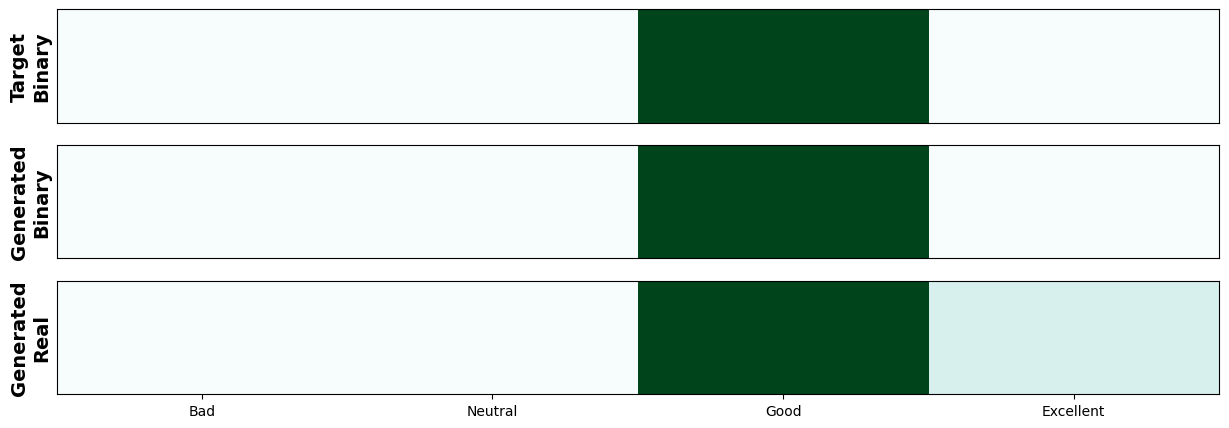

In [43]:
opt.shuffle = False
loader, _, _ = get_poem_dataloader(opt)
ds = loader.dataset

target_index = 0

# targets aligned with h/U/V (dataset order)
text_tgt = torch.as_tensor(ds.text[target_index], device=opt.device).long()         # (15,)
sent_tgt = torch.as_tensor(ds.sentiment[target_index], device=opt.device).float()  # (4,)
len_tgt = torch.as_tensor(ds.length[target_index], device=opt.device).float()    # (15,)

# latent aligned with dataset order
h_target = h[target_index, :]  # (h_dim,)

z_text = torch.mv(U, h_target).unsqueeze(0)
z_sent = torch.mv(V, h_target).unsqueeze(0)
z_len = torch.mv(W, h_target).unsqueeze(0)

with torch.no_grad():
    logits = net_text_de(z_text)                 # (1,15,V)
    text_rec = logits.argmax(-1).squeeze(0)      # (15,)
    sent_rec = net_sent_de(z_sent).squeeze(0)    # (4,)
    len_rec = net_len_de(z_len).squeeze(0)      # (15,)

enc = tiktoken.get_encoding("o200k_base")

# --- decode needs python ints on CPU ---
text_tgt_ids = text_tgt.detach().cpu().tolist()
text_rec_ids = text_rec.detach().cpu().tolist()

print(f'Text Results:')
print(f' > Target:')
print(f'   > {text_tgt_ids}')
print(f'   > {enc.decode(text_tgt_ids)}')
print()
print(f' > Reconstruction:')
print(f'   > {text_rec_ids}')
print(f'   > {enc.decode(text_rec_ids)}')
print()
print(f' > Length:')
print(f'   > Target: {max(0, len_tgt.argmax().item() - 1)}')
print(f'   > Reconstruction: {max(0, len_rec.argmax().item() - 1)}')
print()
print(f'Sentiment Results:')

# --- plotting needs numpy ---
sent_tgt_np = sent_tgt.detach().cpu().numpy()
sent_rec_np = sent_rec.detach().cpu().numpy()
sent_rec_onehot = (np.arange(sent_rec_np.shape[-1]) == np.argmax(sent_rec_np)).astype(np.int64).reshape(1, -1)

fig, ax = plt.subplots(3, 1, figsize=(15, 5))

ax[0].imshow(sent_tgt_np.reshape(1, -1), cmap='BuGn', aspect='auto')
ax[0].set_yticks([]); ax[0].set_xticks([])
ax[0].set_ylabel('Target\nBinary', rotation=90, size=14, weight='bold')

ax[1].imshow(sent_rec_onehot, cmap='BuGn', aspect='auto')
ax[1].set_yticks([]); ax[1].set_xticks([])
ax[1].set_ylabel('Generated\nBinary', rotation=90, size=14, weight='bold')

ax[2].imshow(sent_rec_np.reshape(1, -1), cmap='BuGn', aspect='auto')
ax[2].set_yticks([]); ax[2].set_xticks([])
ax[2].set_xticks(np.arange(4))
ax[2].set_xticklabels(['Bad', 'Neutral', 'Good', 'Excellent'])
ax[2].set_ylabel('Generated\nReal', rotation=90, size=14, weight='bold')

plt.show()

## Disentanglement
### DCI

In [44]:
Cs = []
Zs = []

with torch.no_grad():
    for data_text, data_sent, data_len in loader:
        data_text = data_text.to(opt.device)
        data_sent = data_sent.to(opt.device)
        data_len = data_len.to(opt.device)

        output1 = net_text_en(data_text)

        Z = torch.cat([data_sent, data_len], dim=1)  # (B, 4+15)

        Cs.append(output1.cpu().numpy())
        Zs.append(Z)

C = np.concatenate(Cs, axis=0)
Zs = np.concatenate(Zs, axis=0)

factor_types = ['discrete'] * 19

In [45]:
res = compute_dci(C, Zs, factor_types, probe="rf")
report_dci(res, title='Combined DCI Scores')

--- Combined DCI Scores ---
 > Disentanglement: 0.0147
 > Completeness: 0.0115
 > Informativeness: 0.9684


### IRS

In [46]:
irs_res = compute_irs(C, Zs)

print(f'--- IRS Scores ---')
print(f' > Disentanglement: {round(irs_res["IRS"], 4)}')

--- IRS Scores ---
 > Disentanglement: 0.4522
